# 초기 빠른 모델 테스트

In [1]:
import sys
import os
# Add the project root directory to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from scripts.utils import get_time_series, get_timestamp_index, plot_weather_data, generate_delay_hours, model_errors, plot_prediction

## linear regression

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import logging
from datetime import datetime
random.seed(42)         # Python built-in random module
np.random.seed(42)

In [3]:
# 로깅 설정
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(f"regression_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"),
        logging.StreamHandler()  # 콘솔에도 출력
    ]
)
logger = logging.getLogger(__name__)

# 데이터 로드
logger.info("데이터 로드 시작")

2025-04-08 14:15:55,957 - INFO - 데이터 로드 시작


In [4]:
raw_data = pd.read_csv('../raw_data_20250403.csv')

In [5]:
data = get_timestamp_index(raw_data)

In [6]:
data_seoul_pivot = data[data['city']=='Incheon'].copy()
data_seoul_common = data[data['city']=='Incheon'].copy()

In [7]:
data_seoul_common  = data_seoul_common.groupby('timestamp').first()
data_seoul_common = data_seoul_common[[ 'base_date', 'year', 'month', 'day', 'day_of_week', 'is_holiday', 'base_time', 'hour', 'nx', 'ny', 'admin_district_code','city', 'sub_address']]

In [8]:
data_seoul_pivot['timestamp'] = data_seoul_pivot.index
data_seoul_pivot = data_seoul_pivot.pivot(index='timestamp', columns='category_code', values='measurement_value')

In [9]:
data_seoul_pivot['delay_hours'] = data_seoul_pivot.apply(generate_delay_hours, axis=1)

In [10]:
data_seoul_merged = pd.merge(data_seoul_pivot, data_seoul_common, left_index=True, right_index=True, how='left')

In [11]:
X  = data_seoul_merged[['PTY', 'REH', 'RN1', 'T1H', 'UUU', 'VEC', 'VVV', 'WSD']]
y = np.log1p(data_seoul_merged['delay_hours'])# log transformation of target, to reduce variance of the rain event

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [13]:
models = {
    "LinearRegression": LinearRegression(),
    "XGBoostRegressor": XGBRegressor(n_estimators=200,max_depth=5),
    "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=5),
}

2025-04-08 14:15:56,045 - INFO - LinearRegression 모델 학습 시작
2025-04-08 14:15:56,101 - INFO - LinearRegression 모델 학습 완료
2025-04-08 14:15:56,127 - INFO - LinearRegression - MSE : 0.005227233486062372
2025-04-08 14:15:56,128 - INFO - LinearRegression - MAE : 0.058706925755743315
2025-04-08 14:15:56,129 - INFO - LinearRegression - RMSE : 0.07229960916949947
2025-04-08 14:15:56,129 - INFO - LinearRegression - R2 : -0.7594739028464472
2025-04-08 14:15:56,174 - INFO - XGBoostRegressor 모델 학습 시작
2025-04-08 14:15:56,318 - INFO - XGBoostRegressor 모델 학습 완료
2025-04-08 14:15:56,321 - INFO - XGBoostRegressor - MSE : 0.003766048158087616
2025-04-08 14:15:56,321 - INFO - XGBoostRegressor - MAE : 0.046695878651346195
2025-04-08 14:15:56,321 - INFO - XGBoostRegressor - RMSE : 0.06136813634197812
2025-04-08 14:15:56,321 - INFO - XGBoostRegressor - R2 : -0.26764252423122503
2025-04-08 14:15:56,331 - INFO - RandomForest 모델 학습 시작
2025-04-08 14:15:56,470 - INFO - RandomForest 모델 학습 완료
2025-04-08 14:15:56,478 -

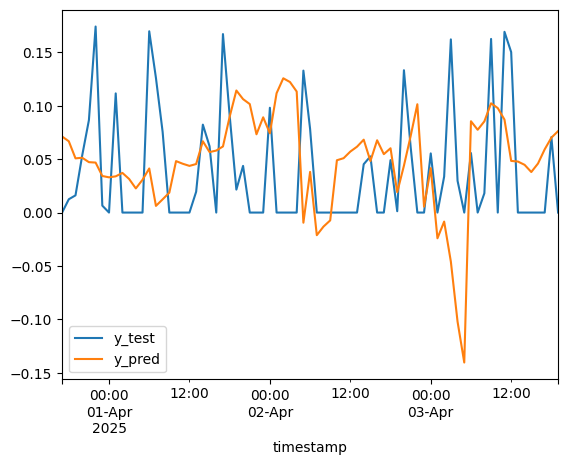

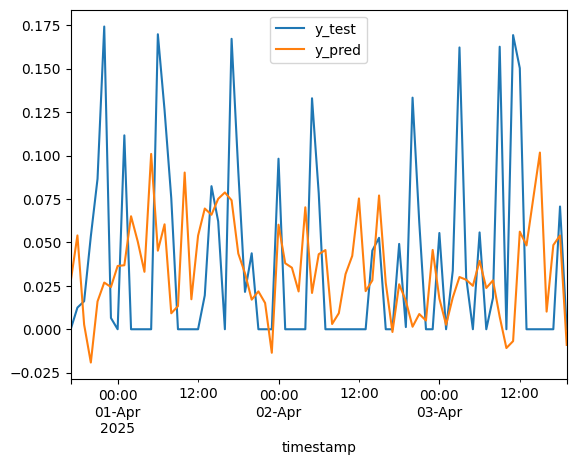

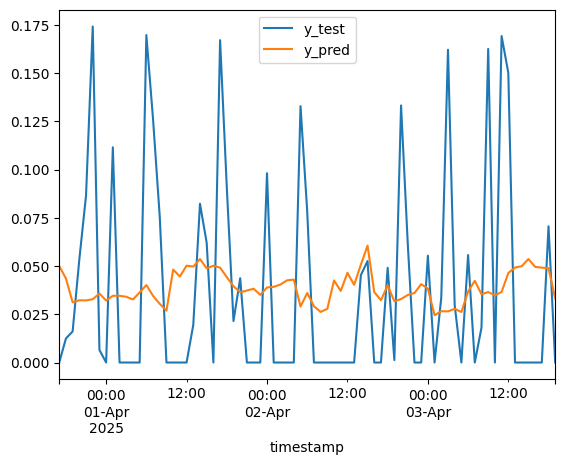

In [14]:

results = {}
predicted_series = {}

for name, model in models.items():
    logger.info(f"{name} 모델 학습 시작")
    try:
        model.fit(X_train, y_train)
        logger.info(f"{name} 모델 학습 완료")

        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        predicted_series[f'y_pred_{name}'] = y_pred

        results[f'{name}_MSE'] = mse
        results[f'{name}_MAE'] = mae
        results[f'{name}_RMSE'] = rmse
        results[f'{name}_R2'] = r2


        logger.info(f"{name} - MSE : {mse}")
        logger.info(f"{name} - MAE : {mae}")
        logger.info(f"{name} - RMSE : {rmse}")
        logger.info(f"{name} - R2 : {r2}")
        # plot
        test_df = pd.DataFrame({
                'y_test': y_test,
                'y_pred': y_pred}, index=X_test.index).sort_index()  # 인덱스(타임스탬프)로 정렬
        test_df.plot()
    except Exception as e:
        logger.error(f"{name} 모델 처리 중 오류: {e}")
    

In [15]:
for name, value in results.items():
    logger.info(f"{name}: {value:.4f}")
logger.info("모델 metrics 테스트 완료")

2025-04-08 14:15:56,662 - INFO - LinearRegression_MSE: 0.0052
2025-04-08 14:15:56,663 - INFO - LinearRegression_MAE: 0.0587
2025-04-08 14:15:56,664 - INFO - LinearRegression_RMSE: 0.0723
2025-04-08 14:15:56,664 - INFO - LinearRegression_R2: -0.7595
2025-04-08 14:15:56,664 - INFO - XGBoostRegressor_MSE: 0.0038
2025-04-08 14:15:56,664 - INFO - XGBoostRegressor_MAE: 0.0467
2025-04-08 14:15:56,665 - INFO - XGBoostRegressor_RMSE: 0.0614
2025-04-08 14:15:56,665 - INFO - XGBoostRegressor_R2: -0.2676
2025-04-08 14:15:56,665 - INFO - RandomForest_MSE: 0.0031
2025-04-08 14:15:56,666 - INFO - RandomForest_MAE: 0.0452
2025-04-08 14:15:56,666 - INFO - RandomForest_RMSE: 0.0555
2025-04-08 14:15:56,667 - INFO - RandomForest_R2: -0.0373
2025-04-08 14:15:56,667 - INFO - 모델 metrics 테스트 완료


In [16]:
model_errors(predicted_series,y_test)

{'y_pred_LinearRegression': {'mse': 0.005227233486062372,
  'mae': 0.058706925755743315,
  'rmse': np.float64(0.07229960916949947),
  'r2': -0.7594739028464472},
 'y_pred_XGBoostRegressor': {'mse': 0.003766048158087616,
  'mae': 0.046695878651346195,
  'rmse': np.float64(0.06136813634197812),
  'r2': -0.26764252423122503},
 'y_pred_RandomForest': {'mse': 0.003081867184740813,
  'mae': 0.045195441162453304,
  'rmse': np.float64(0.05551456732012611),
  'r2': -0.03734889555794574}}

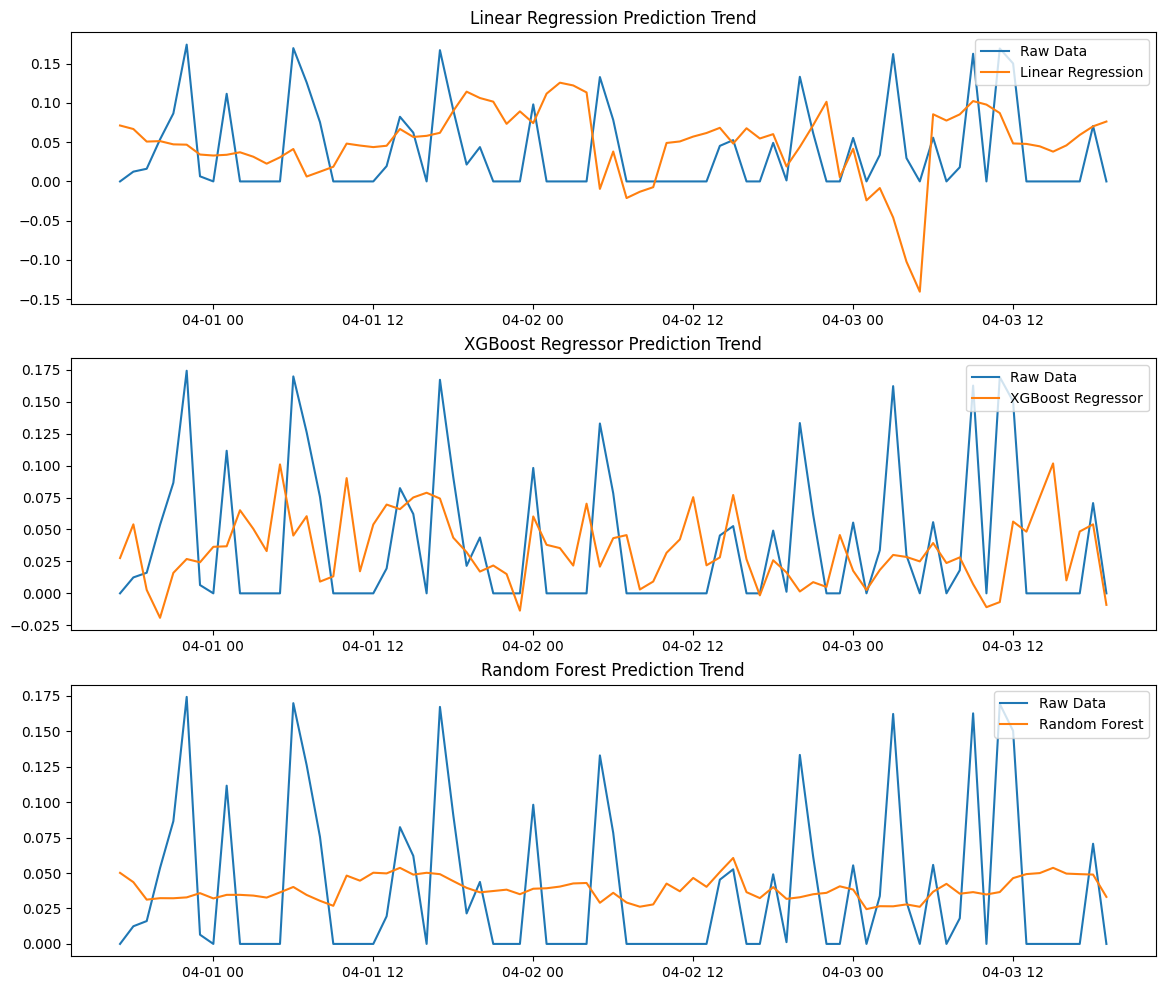

In [17]:
plot_prediction(predicted_series,y_test)